# MOSANIC Tutorial — Mouse Brain (Visium)

End-to-end CCC inference: preprocessing → training → analysis → visualization.

MOSANIC auto-computes everything internally:
- **scVI** cell embeddings (if missing from adata)
- **scFEA** metabolic flux (~2-5 min)
- **ESM-2** gene embeddings (auto-fetches sequences, caches after first run)
- **ChemBERTa** metabolite embeddings (from SMILES, cached)

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# Show MOSANIC's per-stage progress (preprocess + training)
import mosanic
mosanic.set_verbosity("info")

/opt/miniconda/envs/ccc_env/lib/python3.11/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


---
## Step 1: Setup — generate config from minimal inputs

In [2]:
from mosanic import setup

config_path = setup(
    adata_path    = "examples/data/mouse_brain_visium.h5ad",
    output_dir    = "./mosanic_tutorial",
    dataset       = "mouse_brain",
    technology    = "visium",
    organism      = "mouse",
    um_per_pixel  = 1.0,
    cell_type_col = "cell_type_annot",
    epochs        = 80,
)
print(f"Config saved: {config_path}")

[mosanic] Config saved: mosanic_tutorial/config.yaml


Config saved: mosanic_tutorial/config.yaml


---
## Step 2: Preprocess — build heterogeneous graph

Runs 17 steps: spatial graph, LR database, scFEA flux, ESM-2 embeddings, edge construction, etc.

In [3]:
from mosanic import preprocess

# Runs: scVI training (cell embeddings) + scFEA flux + 7-edge graph assembly
graph_path = preprocess(config_path)

# Print relative to current working directory (cleaner output)
from pathlib import Path
try:
    rel = Path(graph_path).relative_to(Path.cwd())
except ValueError:
    rel = graph_path
print(f"\nGraph cached at: {rel}")

[mosanic] Graph saved: mosanic_tutorial/processed/mouse_brain/hetero_ccc_graph.pt



Graph cached at: mosanic_tutorial/processed/mouse_brain/hetero_ccc_graph.pt


---
## Step 3: Train — HetGT encoder + expression decoder

In [4]:
from mosanic import train_model

# Trains the heterogeneous graph transformer for 80 epochs
# Status is printed every 20 epochs (one line per checkpoint)
result = train_model(config_path, device="cuda", epochs=80)
print(f"\n{result.summary()}")

/opt/miniconda/envs/ccc_env/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


[mosanic] training mouse_brain: 7.5M params, 2449 train / 431 val cells, 200 target genes on cuda
[mosanic] epoch     train_loss   val_loss     val_R2    val_r    time


[mosanic]     1/80       1.7966      1.5807  -18.7353   0.0097    0.8s


[mosanic]    21/80       0.3023      0.2968  -0.9138   0.0671    0.4s


[mosanic]    41/80       0.2157      0.2140  -0.0650   0.1777    0.2s


...

[mosanic]   Loss (expr):   0.1239


[mosanic]   R2>0:          95 / 200 genes


[mosanic]   Top 5 R2:  ['0.693', '0.640', '0.546', '0.542', '0.537']


[mosanic] Training complete. Best val R² = 0.0227



MOSANICResult — mouse_brain
  Cells: 3,342
  Genes: 1,592
  Metabolites: 70
  LR pairs: 3,423
  Device: cuda
  Cell types: 5 (Choroid/Ependymal, Exc. neuron (L2/3, Exc. neuron (L5), Inhibitory neuron, Oligodendrocyte)


---
## (Alternative) Reload a trained model without retraining

In [5]:
# from mosanic import load
# result = load("/tmp/mosanic_tutorial/config.yaml", device="cuda")
# 
# import scanpy as sc
# adata = sc.read_h5ad("/mnt/disk-drive/debraj/cci_proj2/CCC/src5/data/raw/mouse_brain_visium.h5ad")
# result.set_cell_types_from_adata(adata, col="cell_type_annot")

---
## 4. LR pair ranking

Default: **intensity** = `attention × mean(expr_L) × mean(expr_R)`

In [6]:
top_lr = result.lr_pairs(top_k=20)
for p in top_lr:
    print(f"{p['rank']:3d}. {p['ligand']:12s} -> {p['receptor']:12s}  score={p['score']:.4f}")

  1. PSAP         -> GPR37L1       score=1.0000
  2. GNAS         -> ADCY1         score=0.9727
  3. PSAP         -> GPR37         score=0.5099
  4. NCAM1        -> NPTN          score=0.4858
  5. CD47         -> SCN1B         score=0.4420
  6. GPI1         -> AMFR          score=0.3997
  7. SYT1         -> SV2B          score=0.3687
  8. GNAS         -> ADCY5         score=0.3672
  9. GNAS         -> ADCY2         score=0.3397
 10. AGRN         -> ATP1A3        score=0.3393
 11. APP          -> LRP10         score=0.2458
 12. BSG          -> SLC16A1       score=0.2358
 13. TSPAN3       -> ADAM10        score=0.2186
 14. CALM1        -> GRM4          score=0.2161
 15. TSPAN5       -> TSPAN13       score=0.2068
 16. SYT1         -> CACNA1E       score=0.2040
 17. APOE         -> APP           score=0.1947
 18. ATP1B1       -> NEGR1         score=0.1929
 19. TRF          -> TFRC          score=0.1806
 20. TSPAN3       -> CLDN11        score=0.1804


In [7]:
# Which ligands matter most for a specific receptor?
for p in result.lr_pairs_for_receptor("ADCY1", top_k=5):
    print(f"  {p['ligand']:12s} -> ADCY1  attn={p['score']:.4f}")

  GNAS         -> ADCY1  attn=1.0000


[mosanic] Top-5 enhanced pairs: [(('WNT3', 'EGFR'), 1.0), (('SIS', 'ITGAV'), 0.9909048676490784), (('FCER2A', 'ITGAV'), 0.986356258392334), (('FCER2A', 'ITGB3'), 0.9830116033554077), (('FCER2A', 'ITGAM'), 0.9824426770210266)]


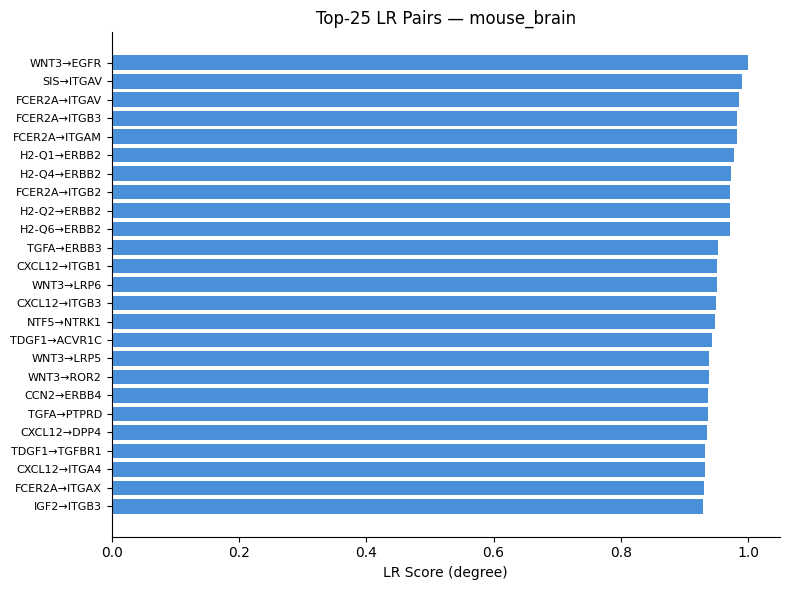

In [8]:
result.plot_lr_ranking(top_k=25)
plt.show()

## 5. MR pair ranking

Default: `attention × mean_flux × mean_receptor_expr`

In [9]:
top_mr = result.mr_pairs(top_k=10)
for p in top_mr:
    print(f"{p['rank']:3d}. {p['metabolite']:20s} -> {p['receptor']:12s}  "
          f"score={p['score']:.3f}  flux={p['mean_flux']:.4f}  expr={p['mean_receptor_expr']:.3f}")

  1. GMP                  -> PDE2A         score=1.000  flux=0.0632  expr=0.135
  2. Cysteine             -> SLC7A11       score=0.956  flux=0.1052  expr=0.078
  3. Cholesterol          -> RORA          score=0.941  flux=0.0611  expr=0.132
  4. Glucose              -> GPR17         score=0.609  flux=0.0705  expr=0.074
  5. UDP-N-acetylglucosamine -> SLC2A1        score=0.590  flux=0.1087  expr=0.132
  6. Deoxyadenosine       -> SLC29A2       score=0.586  flux=0.1749  expr=0.058
  7. Glycine              -> GLRB          score=0.564  flux=0.0322  expr=0.150
  8. Glucose              -> SLC2A8        score=0.510  flux=0.0705  expr=0.062
  9. Glucose              -> SLC2A6        score=0.509  flux=0.0705  expr=0.062
 10. Cholesterol          -> LDLR          score=0.497  flux=0.0611  expr=0.070


## 6. Spatial communication maps

[mosanic] Top-5 enhanced pairs: [(('WNT3', 'EGFR'), 1.0), (('SIS', 'ITGAV'), 0.9909048676490784), (('FCER2A', 'ITGAV'), 0.986356258392334), (('FCER2A', 'ITGB3'), 0.9830116033554077), (('FCER2A', 'ITGAM'), 0.9824426770210266)]


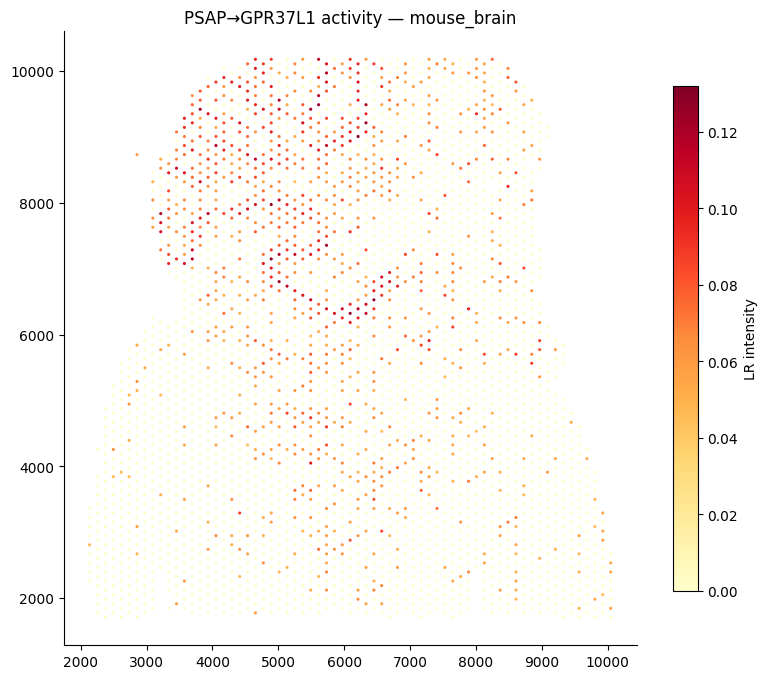

In [10]:
# Top LR pair spatial activity
top = result.lr_pairs(top_k=1)[0]
result.plot_spatial(top['ligand'], top['receptor'])
plt.show()

[mosanic] Top-5 enhanced pairs: [(('WNT3', 'EGFR'), 1.0), (('SIS', 'ITGAV'), 0.9909048676490784), (('FCER2A', 'ITGAV'), 0.986356258392334), (('FCER2A', 'ITGB3'), 0.9830116033554077), (('FCER2A', 'ITGAM'), 0.9824426770210266)]


[mosanic] Top-5 enhanced pairs: [(('WNT3', 'EGFR'), 1.0), (('SIS', 'ITGAV'), 0.9909048676490784), (('FCER2A', 'ITGAV'), 0.986356258392334), (('FCER2A', 'ITGB3'), 0.9830116033554077), (('FCER2A', 'ITGAM'), 0.9824426770210266)]


[mosanic] Top-5 enhanced pairs: [(('WNT3', 'EGFR'), 1.0), (('SIS', 'ITGAV'), 0.9909048676490784), (('FCER2A', 'ITGAV'), 0.986356258392334), (('FCER2A', 'ITGB3'), 0.9830116033554077), (('FCER2A', 'ITGAM'), 0.9824426770210266)]


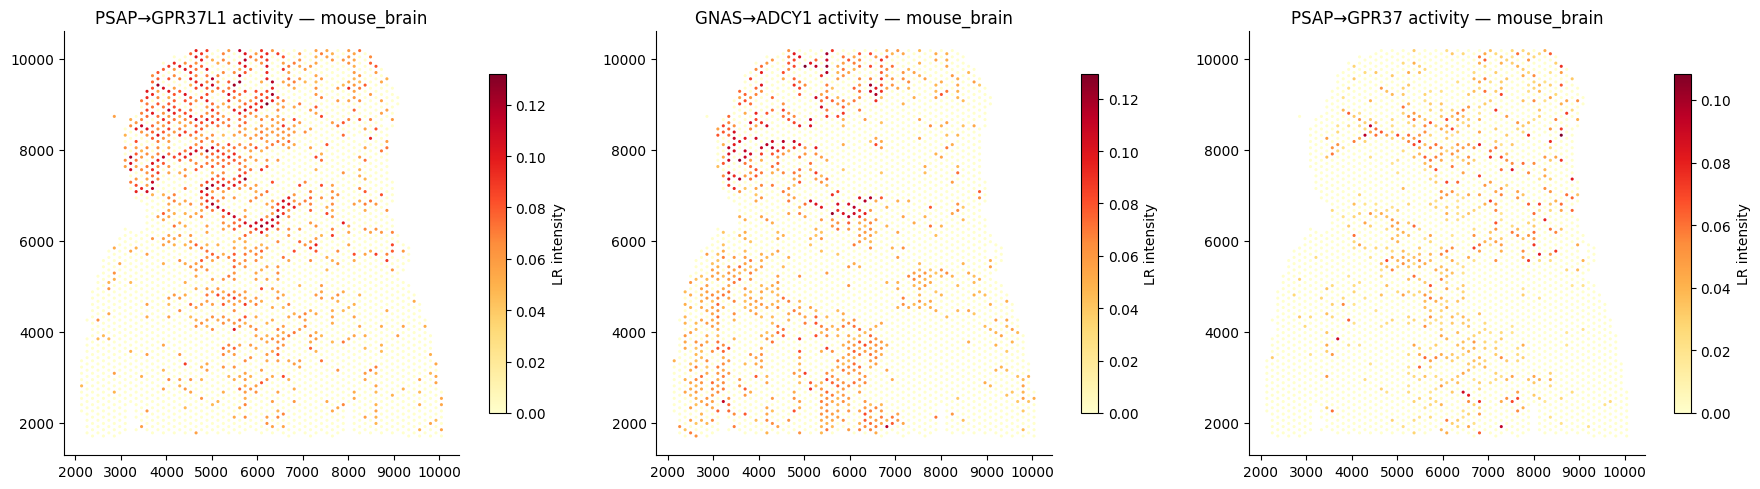

In [11]:
# Multiple pairs side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, p in enumerate(result.lr_pairs(top_k=3)):
    result.plot_spatial(p['ligand'], p['receptor'], ax=axes[i], s=5)
plt.tight_layout()
plt.show()

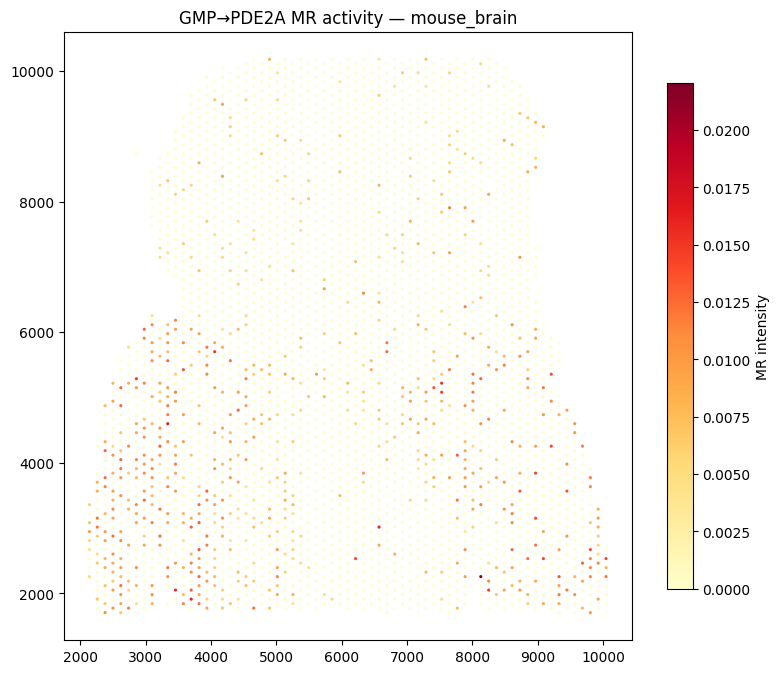

In [12]:
# MR spatial activity
top_mr_pair = result.mr_pairs(top_k=1)[0]
result.plot_spatial_mr(top_mr_pair['metabolite'], top_mr_pair['receptor'])
plt.show()

## 7. Hub-score — the canonical scalar

`result.hub_scores(...)` is MOSANIC's per-gene hub-score: the sum of incoming
attention into each gene, averaged across heads and encoder layers, optionally
restricted to a channel mask. The same equation yields three named variants:

- `channels="all"` — canonical hub-score (ε₂ + ε₄ combined)
- `channels="lr"`  — LR-network hub (ε₂ only)
- `channels="mr"`  — MR hub (ε₄ only)

In [13]:
# Canonical hub-score — ε₂ + ε₄ combined
hubs = result.hub_scores(top_k=15)
hubs.head(15)


,gene,hub_score,rank
0,KCNJ4,2.0,1
1,SCARB1,2.0,2
2,GRIN2B,2.0,3
3,GRIN2C,2.0,4
4,GRIN2D,2.0,5
5,LDLR,2.0,6
6,GPR17,2.0,7
7,GRM4,2.0,8
8,ADORA1,2.0,9
9,GLRA2,2.0,10


In [14]:
# Channel-restricted variants — paper §4.1 and §4.2
lr_hubs = result.hub_scores(top_k=10, channels="lr")
mr_hubs = result.hub_scores(top_k=10, channels="mr")

print("LR-network hubs (ε₂ only):", lr_hubs.gene.tolist())
print("MR hubs (ε₄ only):        ", mr_hubs.gene.tolist())


LR-network hubs (ε₂ only): ['KCNJ4', 'SCN1A', 'MPZL2', 'MSN', 'EPHB4', 'MUC15', 'EPHA6', 'NPR1', 'EDNRB', 'GPR84']
MR hubs (ε₄ only):         ['SLC22A4', 'SLC7A5', 'GRIN2C', 'GRIN2B', 'SLC2A3', 'KCNJ4', 'SLC43A1', 'SLC38A2', 'SLC38A1', 'SLC36A1']


## 9. Cell-type communication


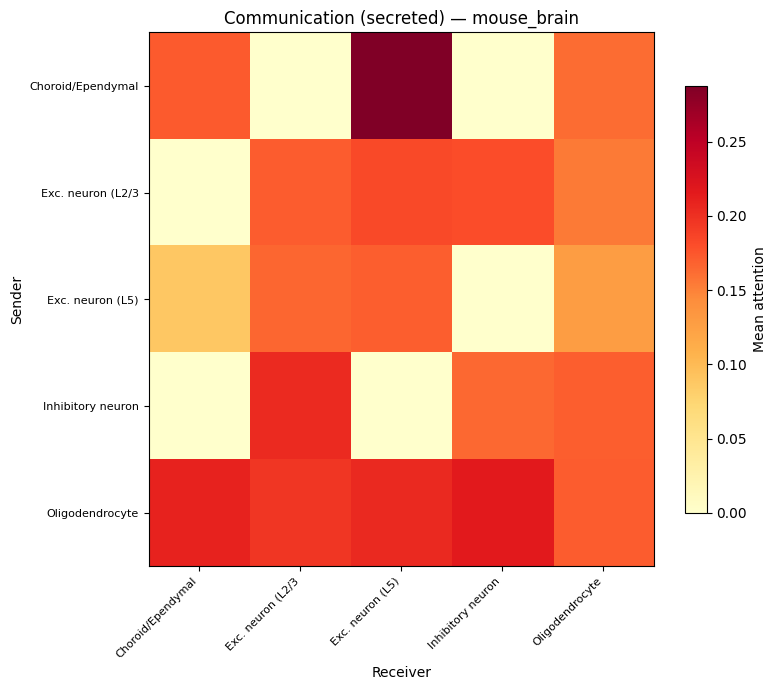

In [15]:
result.plot_communication_matrix(channel="secreted")
plt.show()

In [16]:
# Top sender-receiver pairs
for h in result.communication_hotspots(top_k=5):
    print(f"  {h['sender']:25s} -> {h['receiver']:25s}  score={h['score']:.4f}")

[mosanic] Top-5 enhanced pairs: [(('WNT3', 'EGFR'), 1.0), (('SIS', 'ITGAV'), 0.9909048676490784), (('FCER2A', 'ITGAV'), 0.986356258392334), (('FCER2A', 'ITGB3'), 0.9830116033554077), (('FCER2A', 'ITGAM'), 0.9824426770210266)]


  Choroid/Ependymal         -> Exc. neuron (L5)           score=0.2877
  Oligodendrocyte           -> Inhibitory neuron          score=0.2166
  Oligodendrocyte           -> Choroid/Ependymal          score=0.2094
  Oligodendrocyte           -> Exc. neuron (L5)           score=0.2047
  Inhibitory neuron         -> Exc. neuron (L2/3          score=0.2035


[mosanic] Top-5 enhanced pairs: [(('WNT3', 'EGFR'), 1.0), (('SIS', 'ITGAV'), 0.9909048676490784), (('FCER2A', 'ITGAV'), 0.986356258392334), (('FCER2A', 'ITGB3'), 0.9830116033554077), (('FCER2A', 'ITGAM'), 0.9824426770210266)]


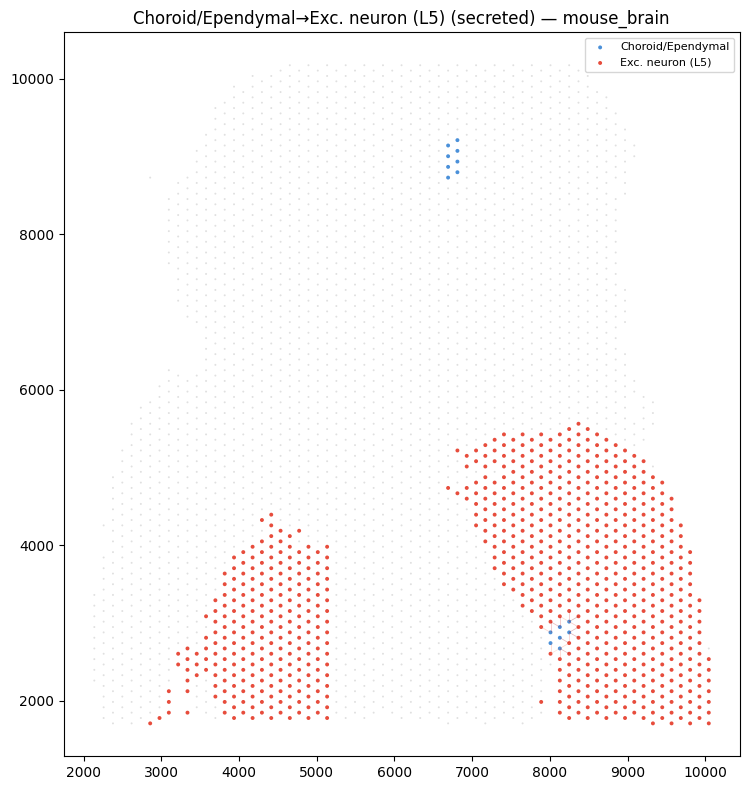

In [17]:
# Communication edges between top pair
hs = result.communication_hotspots(top_k=1)[0]
result.plot_communication_edges(hs['sender'], hs['receiver'])
plt.show()

## 11. Niches from learned cell embeddings


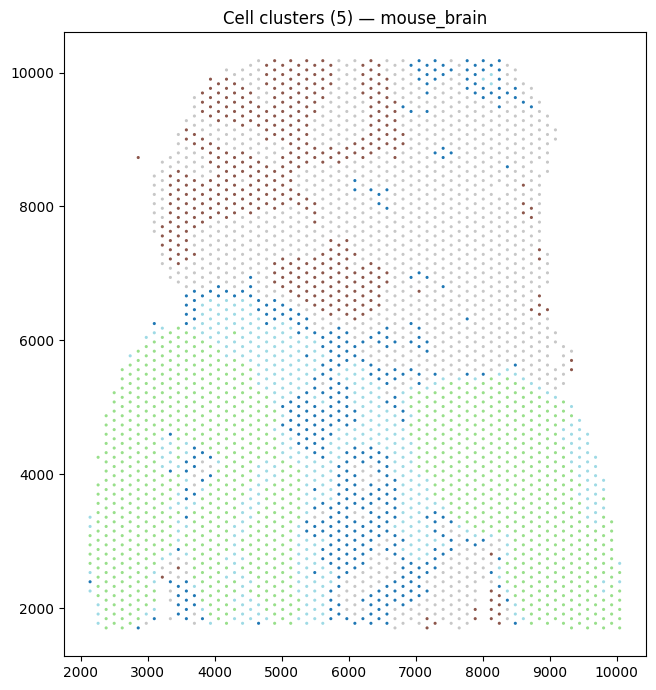

In [18]:
result.plot_clusters(n_clusters=5)
plt.show()

## 10. In-silico gene knockout


In [19]:
# Suggest genes for knockout
for s in result.suggest_knockouts(top_k=10):
    print(f"  {s['rank']:2d}. {s['gene']:15s}  LR_rank={s['lr_rank']}")

[mosanic] Extracting per-edge attention...


[mosanic] Extraction done in 0.1s


[mosanic]   cell__secreted__cell: 19484 edges, mean=0.1715, max=1.0000


[mosanic]   cell__metabolite__cell: 19484 edges, mean=0.1715, max=1.0000


[mosanic]   cell__intracellular__cell: 3342 edges, mean=1.0000, max=1.0000


...

[mosanic]   Exc. neuron (L5->Exc. neuron (L5->Exc. neuron (L2  prod=0.2609  dist=137+138px


[mosanic]   Exc. neuron (L5->Exc. neuron (L5->Exc. neuron (L5  prod=0.2466  dist=138+138px


[mosanic] Metabolite 2-hop relays (top-10%): 1553


[mosanic] Cross-channel 2-hop relays: 1494


   1. PSAP             LR_rank=1
   2. GPR37L1          LR_rank=1
   3. GNAS             LR_rank=2
   4. ADCY1            LR_rank=2
   5. GPR37            LR_rank=3
   6. NPTN             LR_rank=4
   7. NCAM1            LR_rank=4
   8. CD47             LR_rank=5
   9. SCN1B            LR_rank=5
  10. AMFR             LR_rank=6


In [20]:
# Knock out a single hub and inspect the gene-level effect
gene_to_ko = result.hub_scores(top_k=1, channels="lr").gene.iloc[0]
ko = result.knockout_gene(gene_to_ko)
print(f"Knocked out {gene_to_ko}: ΔR² = {ko['delta_r2']:+.4f}  "
      f"({ko['n_edges_removed']} attention edges removed)")

Knocked out KCNJ4: ΔR² = -0.0000  (3 attention edges removed)


[mosanic] Running channel ablation analysis...


[mosanic]   Ablate        secreted: MSE 0.2725 (delta=+0.0016, +0.6%)


[mosanic]   Ablate      metabolite: MSE 0.2725 (delta=+0.0016, +0.6%)


[mosanic]   Ablate   intracellular: MSE 0.2720 (delta=+0.0011, +0.4%)


[mosanic]   Ablate       expresses: MSE 0.2709 (delta=+0.0000, +0.0%)


...

[mosanic]   ('cell', 'intracellular', 'cell'): delta_mse=+0.0011 (0.4%)


[mosanic]   ('cell', 'expresses', 'gene'): delta_mse=+0.0000 (0.0%)


[mosanic]   ('gene', 'interacts', 'gene'): delta_mse=+0.0000 (0.0%)


[mosanic]   ('cell', 'flux', 'metabolite'): delta_mse=+0.0000 (0.0%)


[mosanic]   ('metabolite', 'sensed_by', 'gene'): delta_mse=+0.0000 (0.0%)


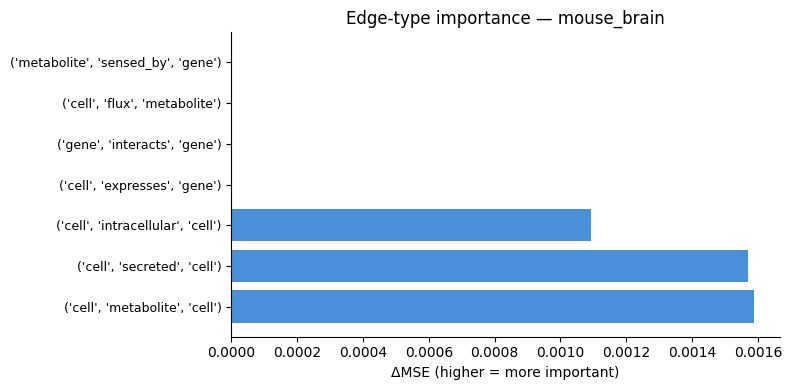

In [21]:
# Channel importance
result.plot_channel_importance()
plt.show()

Knocking out the top-2 LR-network hubs: ['KCNJ4', 'SCN1A']


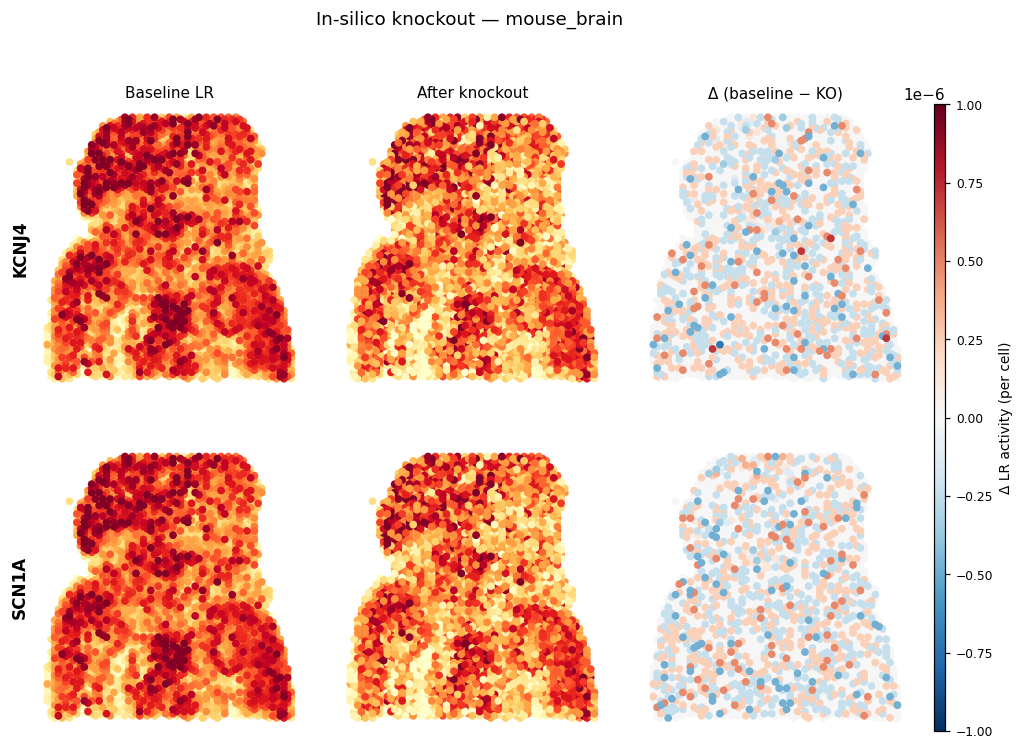

In [22]:
# Side-by-side spatial maps: baseline LR | post-knockout LR | Δ for each gene
# Take the top-2 LR-network hubs from this dataset — they should produce the
# clearest spatial signal.
top_hubs = result.hub_scores(top_k=2, channels="lr").gene.tolist()
print(f"Knocking out the top-2 LR-network hubs: {top_hubs}")
result.plot_knockout_comparison(top_hubs)
plt.show()

## 10. Hub fan-out — multiplexer pattern

`result.hub_fanout(gene, top_k=...)` traces the downstream LR pairs converging
on a given receptor gene. This surfaces multiplexer-style hubs that integrate
many incoming ligand signals into a single downstream pathway.

In [23]:
# Take the top LR-network hub from this dataset and trace its fan-out
top_hub = result.hub_scores(top_k=1, channels="lr").gene.iloc[0]
fanout = result.hub_fanout(top_hub, top_k=10)
print(f"\n{top_hub} fan-out (top 10 incoming LR pairs):")
fanout



KCNJ4 fan-out (top 10 incoming LR pairs):


,ligand,receptor,score,rank
0,LIN7B,KCNJ4,0.014645,1
1,LIN7C,KCNJ4,0.012941,2
2,IL16,KCNJ4,0.006568,3


## 12. Relay-chain detection


In [24]:
# 2-hop relay chains within each channel
relays = result.relays(top_pct=[20])
sec_chains = relays.get('2hop_secreted', [])
met_chains = relays.get('2hop_metabolite', [])
print(f"Secreted 2-hop chains : {len(sec_chains)}")
print(f"Metabolite 2-hop chains: {len(met_chains)}")

# Tabulate the strongest secreted chains
import pandas as pd
df = pd.DataFrame([
    {
        "rank": rank,
        "sender":  chain["ct_a"],
        "relay":   chain["ct_b"],
        "receiver":chain["ct_c"],
        "ab_attn": round(chain["ab_attn"], 3),
        "bc_attn": round(chain["bc_attn"], 3),
        "product": round(chain["product"], 3),
        "dist_ab": round(chain["dist_ab"], 1),
        "dist_bc": round(chain["dist_bc"], 1),
    }
    for rank, chain in enumerate(sec_chains[:8], start=1)
])
df

[mosanic] Extracting per-edge attention...


[mosanic] Extraction done in 0.1s


[mosanic]   cell__secreted__cell: 19484 edges, mean=0.1715, max=1.0000


[mosanic]   cell__metabolite__cell: 19484 edges, mean=0.1715, max=1.0000


[mosanic]   cell__intracellular__cell: 3342 edges, mean=1.0000, max=1.0000


...

[mosanic]   Exc. neuron (L5->Exc. neuron (L5->Exc. neuron (L5  prod=0.2466  dist=138+138px


[mosanic] Metabolite 2-hop relays (top-10%): 1553


[mosanic] Cross-channel 2-hop relays: 1494


Secreted 2-hop chains : 100
Metabolite 2-hop chains: 100


,rank,sender,relay,receiver,ab_attn,bc_attn,product,dist_ab,dist_bc
0,1,Oligodendrocyte,Oligodendrocyte,Oligodendrocyte,0.491,0.576,0.282,137.6,138.4
1,2,Exc. neuron (L5),Exc. neuron (L5),Exc. neuron (L2/3,0.640,0.408,0.261,137.0,137.6
2,3,Exc. neuron (L5),Exc. neuron (L5),Exc. neuron (L5),0.617,0.400,0.247,137.6,138.4
3,4,Exc. neuron (L5),Exc. neuron (L5),Exc. neuron (L5),0.594,0.409,0.243,138.0,138.4
4,5,Exc. neuron (L5),Exc. neuron (L5),Exc. neuron (L5),0.407,0.594,0.241,137.0,138.0
5,6,Oligodendrocyte,Exc. neuron (L5),Oligodendrocyte,0.461,0.509,0.235,138.0,138.0
6,7,Exc. neuron (L5),Exc. neuron (L5),Exc. neuron (L5),0.445,0.527,0.234,138.4,138.4
7,8,Exc. neuron (L5),Exc. neuron (L5),Exc. neuron (L5),0.376,0.617,0.232,138.4,137.6


In [25]:
# Relay hub cells
for h in result.relay_hubs(top_k=5):
    print(f"  Cell {h['cell_idx']} ({h['cell_type']}): {h['n_chains']} chains")

[mosanic] Extracting per-edge attention...


[mosanic] Extraction done in 0.1s


[mosanic]   cell__secreted__cell: 19484 edges, mean=0.1715, max=1.0000


[mosanic]   cell__metabolite__cell: 19484 edges, mean=0.1715, max=1.0000


[mosanic]   cell__intracellular__cell: 3342 edges, mean=1.0000, max=1.0000


...

[mosanic]   Exc. neuron (L5->Exc. neuron (L5->Exc. neuron (L2  prod=0.2609  dist=137+138px


[mosanic]   Exc. neuron (L5->Exc. neuron (L5->Exc. neuron (L5  prod=0.2466  dist=138+138px


[mosanic] Metabolite 2-hop relays (top-10%): 1553


[mosanic] Cross-channel 2-hop relays: 1494


  Cell 256 (Exc. neuron (L5)): 12 chains
  Cell 3054 (Exc. neuron (L5)): 9 chains
  Cell 2864 (Oligodendrocyte): 9 chains
  Cell 1401 (Oligodendrocyte): 8 chains
  Cell 2241 (Oligodendrocyte): 8 chains


## 12. Cross-channel relay

Relay chains that switch modality at the centre cell — a protein-LR signal
flowing into a cell that then sends a metabolite-MR signal to its neighbour
(or the converse). These cascades surface receptors and transporters acting
as protein↔metabolite "bridges".

In [26]:
# Cross-channel chains: a secreted-LR signal converted into a metabolite-MR signal
# (or vice versa) at the centre cell of the chain.
xrelays = relays.get('2hop_cross_channel', [])
print(f"Cross-channel cascades found: {len(xrelays)}")

import pandas as pd
df = pd.DataFrame([
    {
        "rank":    rank,
        "sender":  chain["ct_a"],
        "relay":   chain["ct_b"],
        "receiver":chain["ct_c"],
        "ab_attn": round(chain["ab_attn"], 3),
        "bc_attn": round(chain["bc_attn"], 3),
        "product": round(chain["product"], 3),
    }
    for rank, chain in enumerate(xrelays[:8], start=1)
])
df

Cross-channel cascades found: 100


,rank,sender,relay,receiver,ab_attn,bc_attn,product
0,1,Oligodendrocyte,Oligodendrocyte,Oligodendrocyte,0.491,0.608,0.298
1,2,Exc. neuron (L5),Exc. neuron (L5),Exc. neuron (L5),0.617,0.435,0.268
2,3,Exc. neuron (L5),Exc. neuron (L5),Exc. neuron (L2/3,0.640,0.397,0.254
3,4,Exc. neuron (L5),Exc. neuron (L5),Exc. neuron (L2/3,0.607,0.414,0.251
4,5,Oligodendrocyte,Oligodendrocyte,Oligodendrocyte,0.431,0.557,0.240
5,6,Exc. neuron (L5),Exc. neuron (L5),Exc. neuron (L5),0.445,0.539,0.240
6,7,Exc. neuron (L5),Exc. neuron (L5),Exc. neuron (L5),0.594,0.403,0.239
7,8,Oligodendrocyte,Oligodendrocyte,Oligodendrocyte,0.391,0.610,0.238


## 13. Benchmark against an independent LR catalogue

`result.evaluate_against(db_path)` computes AUROC and AUPR of MOSANIC's LR
scores against any external reference catalogue (OmniPath, ConnectomeDB,
NeuronChat, your own curated list, …). Useful for sanity-checking how MOSANIC
ranks your tissue's LR vocabulary against a held-out gold standard.

In [27]:
# Mouse dataset → use NeuronChatDB for evaluation
from pathlib import Path
# Bundled with MOSANIC under mosanic/databases/ (relative to package install)
neurochat_db = Path(mosanic.__path__[0]) / "databases" / "neuronchat_mouse_db.csv"
if not neurochat_db.exists():
    # Fall back to project-local path for development
    neurochat_db = Path("../src5/data/databases/neuronchat_mouse_db.csv")
if neurochat_db.exists():
    metrics = result.evaluate_against(
        str(neurochat_db),
        ligand_col="lig_contributor",
        receptor_col="receptor_subunit",
    )
    print(f"AUROC vs NeuronChatDB: {metrics['auroc']:.3f}")
    print(f"AUPR  vs NeuronChatDB: {metrics['aupr']:.3f}")
    print(f"      n_positives={metrics['n_positives']}, n_vocab={metrics['n_pairs_in_vocab']}")
else:
    print("(NeuronChatDB CSV not found; skipping evaluation cell)")

AUROC vs NeuronChatDB: 0.639
AUPR  vs NeuronChatDB: 0.012
      n_positives=28, n_vocab=3423


## 14. Export results


In [28]:
pd.DataFrame(result.lr_pairs(top_k=100)).to_csv("top100_lr.csv", index=False)
pd.DataFrame(result.mr_pairs(top_k=50)).to_csv("top50_mr.csv", index=False)

comm = result.communication_matrix(channel="secreted")
pd.DataFrame(
    comm['matrix'],
    index=comm['cell_type_names'],
    columns=comm['cell_type_names']
).to_csv("comm_matrix.csv")

print("Exported: top100_lr.csv, top50_mr.csv, comm_matrix.csv")

Exported: top100_lr.csv, top50_mr.csv, comm_matrix.csv
